In [44]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import Field

In [45]:
load_dotenv()

True

In [46]:
parent_llm = ChatGroq(model='openai/gpt-oss-120b')
subgraph_llm = ChatGroq(model='llama-3.3-70b-versatile')

In [47]:
class ParentState(TypedDict):
    topic: str
    generate_eng: str
    hindi_translator: str

In [54]:
def hindi_translator(state: ParentState):
    prompt = f"""You are a helpful assistant please translate the input text
    into hindi text, Do not add any extra content. Just translate naturally
    input_text: {state['generate_eng']}"""

    result = subgraph_llm.invoke(prompt).content
    return {'hindi_translator': result}


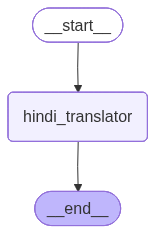

In [55]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('hindi_translator', hindi_translator)

subgraph_builder.add_edge(START, 'hindi_translator')
subgraph_builder.add_edge('hindi_translator', END)

subgraph = subgraph_builder.compile()

subgraph

In [56]:
def generate_eng(state: ParentState):
    prompt = f"""You are a helpful assistant please explain the given topic carefully
    topic: {state['topic']}
    """
    result = parent_llm.invoke(prompt).content

    return {'generate_eng': result}


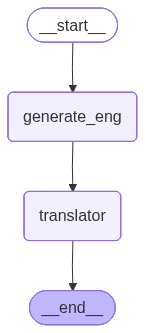

In [57]:
parentGraph_builder = StateGraph(ParentState)

parentGraph_builder.add_node('generate_eng', generate_eng)
parentGraph_builder.add_node('translator', subgraph)

parentGraph_builder.add_edge(START, 'generate_eng')
parentGraph_builder.add_edge('generate_eng', 'translator')
parentGraph_builder.add_edge('translator', END)


parentGraph = parentGraph_builder.compile()

parentGraph

In [58]:
initial_state = {'topic': 'AI future'}
final_state = parentGraph.invoke(initial_state)

In [59]:
final_state

{'topic': 'AI future',
 'generate_eng': '**The Future of Artificial Intelligence (AI): A Careful Overview**\n\nArtificial intelligence is already reshaping many aspects of our lives, from how we search for information to how companies automate routine tasks. Looking ahead, the trajectory of AI promises both remarkable opportunities and significant challenges. Below is a comprehensive, balanced look at the key dimensions that will shape the future of AI over the coming decade and beyond.\n\n---\n\n## 1. Technical Progress\n\n| Area | Current State (2024) | Expected Advances (5‑10\u202fyears) | Long‑Term Horizon (20‑30\u202fyears) |\n|------|----------------------|--------------------------------|--------------------------------|\n| **Machine Learning Models** | Large language models (LLMs) with billions of parameters; transformer‑based vision and multimodal models. | More efficient architectures (sparse, mixture‑of‑experts), better few‑shot learning, reduced need for massive data. | Gen